# Gubbins Recomb Event Mapping to Rv Paralogs - Processing

# Import Statements

In [195]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import scipy.stats

%matplotlib inline

In [196]:
import gravis as gv
import networkx as nx

In [197]:
import ast


In [198]:
from tqdm import tqdm

In [199]:
import screed
import mmh3

In [200]:
from Bio import SeqIO


In [201]:
import json

In [202]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

In [203]:
import subprocess

#### Pandas Viewing Settings

In [204]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Import custom utils functions

In [205]:
%load_ext autoreload
%autoreload 2
    
from gcutils.general import Rv_dist, count_substitutions_in_cs, calculate_gc_content_perwindow

from gcutils.eventtoparalogcomparison import insertSNPs_IntoRef, insert_ParentSNPs_IntoRef

from gcutils.eventtoparalogcomparison import extract_EventInfo, Compare_RE_Vs_Paralog_Hashes

from gcutils.eventtoparalogcomparison import compare_EventSeq_kmers_To_Paralogs_V2

from gcutils.eventtoparalogcomparison import check_snp_overlap_V2 #, check_snp_overlap

from gcutils.eventtoparalogcomparison import RunEventMapping_to_HmMapParalogs_V1 

from gcutils.eventtoparalogcomparison import getEventKmerMatchInfo_TopParalogMatches

from gcutils.eventtoparalogcomparison import distribute_mGCE_donor_acceptor_counts_UnqParalogRegions, summarize_HmPair_MappedEvent_counts 

from gcutils.homologymap_graph import CreatePR_DiGraph, CreatePR_UGraph
from gcutils.homologymap_graph import infer_HmMap_ParalogSet_Labels, add_PR_SetID_to_graph, subset_graph_by_PR_SetIDs, summarize_graph_stats



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Extra Functions

# Parse H37Rv genome sequence

In [207]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"
H37Rv_FA = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.fasta"

H37Rv_Seq = SeqIO.read(H37Rv_FA, "fasta").seq
len(H37Rv_Seq)

4411532

# Import/parse processed H37rv genome annotations

In [208]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [209]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Define paths to H37Rv genome masking schemes

In [210]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


## Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [211]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [212]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [213]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


# Parse `Mtb151CI` Isolate Metadata

In [214]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [215]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [216]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


In [217]:
SampleID_To_PrimLineage_Dict = WGA151CI_ID_To_PrimLineage_Dict
SampleID_To_SubLineage_Dict = WGA151CI_ID_To_SubLineage_Dict


In [218]:
WGA151CI_AsmSummary_DF.query("PrimaryLineage == 'lineage3'")

,SampleID,numContigs_Complete,Flye_CircContig_Cov,PrimaryLineage,Lineage,Dataset_Tag,AsmApproach
16,N0004,1,259,lineage3,lineage3,ChinerOms_2019,PBrs2_LR_Flye_I3_SR_Pilon
17,N1274,1,366,lineage3,lineage3,ChinerOms_2019,PBrs2_LR_Flye_I3_SR_Pilon
18,N0054,1,225,lineage3,lineage3,ChinerOms_2019,PBrs2_LR_Flye_I3_SR_Pilon
56,QC-3,1,70,lineage3,lineage3,Peker2021,ONT9.4_LR_FlyeI3M_SR_Pilon_PolyPolish
57,QC-9,1,37,lineage3,lineage3,Peker2021,ONT9.4_LR_FlyeI3M_SR_Pilon_PolyPolish
58,QC-5,1,111,lineage3,lineage3,Peker2021,ONT9.4_LR_FlyeI3M_SR_Pilon_PolyPolish
112,mada_1-30,1,115,lineage3,lineage3.1.1,Hall2022,ONT9.4_LR_FlyeI3M_SR_Pilon_PolyPolish


In [219]:
WGA151CI_AsmSummary_DF.query("SampleID == 'TB3251'")

,SampleID,numContigs_Complete,Flye_CircContig_Cov,PrimaryLineage,Lineage,Dataset_Tag,AsmApproach
33,TB3251,1,497,lineage4,"lineage4,lineage4.2,lineage4.2.1",TB_Portals_24CI_R1,PBrs2_LR_Flye_I3_SR_Pilon


In [220]:
WGA151CI_AsmSummary_DF.query("SampleID == 'TB3334'")

,SampleID,numContigs_Complete,Flye_CircContig_Cov,PrimaryLineage,Lineage,Dataset_Tag,AsmApproach
39,TB3334,1,689,lineage4,"lineage4,lineage4.1,lineage4.1.2",TB_Portals_24CI_R1,PBrs2_LR_Flye_I3_SR_Pilon


In [221]:
WGA151CI_AsmSummary_DF.query("SampleID == 'mada_2-31'")

,SampleID,numContigs_Complete,Flye_CircContig_Cov,PrimaryLineage,Lineage,Dataset_Tag,AsmApproach
113,mada_2-31,1,33,lineage4,lineage4.1,Hall2022,ONT9.4_LR_FlyeI3M_SR_Pilon_PolyPolish


# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [222]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Variants from the homology map alignments (For each pairwise alignment between PRs)
RvHmMap_Var_PerAln_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv"
RvHmMap_Var_PerAln_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv"



### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [223]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [224]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")
HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [225]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

#### Peak at head of each HmMap Regions DFs

In [226]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [227]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [228]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [229]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [230]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

In [231]:
HmMap_Aln_k19w19_NoOverlap_DF.head(5)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0,PR_Set_4


### Parse in HomologyMap Alignment Variants DFs

In [232]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")


In [233]:
Mtb_HM_Var_DF.shape

(79508, 14)

In [234]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 14)

In [235]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(52699, 6)

### Parse in HomologyMap Alignment Variants DFs

In [236]:
### paralog variants - Improved per alignment `cs` tag approach 
Mtb_HM_Var_PR_DF = pd.read_csv(RvHmMap_Var_PerAln_TSV, sep="\t")
print(Mtb_HM_Var_PR_DF.shape)

Mtb_HM_Var_PR_SNPs_DF = pd.read_csv(RvHmMap_Var_PerAln_SNPs_TSV, sep="\t")
print(Mtb_HM_Var_PR_SNPs_DF.shape)

(60402, 20)
(50203, 20)


In [237]:
Mtb_HM_Var_PR_SNPs_DF.head(4)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [238]:
TarCol = ['Target_Name', 'Target_Start', 'Target_End', 'Ref', 'Alt', 'SNP'] 

Mtb_HM_Var_PR_SNPs_Trim_DF = Mtb_HM_Var_PR_SNPs_DF[TarCol]

print(Mtb_HM_Var_PR_SNPs_Trim_DF.shape)

Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF = Mtb_HM_Var_PR_SNPs_Trim_DF.drop_duplicates()

print(Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.shape)


(50203, 6)
(41454, 6)


In [239]:
Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.head(3)

,Target_Name,Target_Start,Target_End,Ref,Alt,SNP
0,NC_000962.3,3082657,3082658,T,C,True
1,NC_000962.3,3082660,3082661,C,A,True
2,NC_000962.3,3082667,3082668,G,A,True


In [240]:
# Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
# Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

# print(Mtb_HM_Var_DF.shape)
# print(Mtb_HM_Var_SNPs_DF.shape)

In [241]:
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [242]:
HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [243]:
HmMap_Aln_k19w19_NoOverlap_DF["PR_SetID"].nunique()

70

In [244]:
HmMapRegs_ParaRegs_k19w19_DF["PR_SetID"].nunique()

70

# Parse `Mtb-151-MainAnalysis` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [245]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

i_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = i_Gubbins_V1_OutputDir

i_Gubbins_OutPrefix = "Gubbins"

i_Gubbins_FullPrefix_PATH  = f"{i_Gubbins_V1_OutputDir}/{i_Gubbins_OutPrefix}"

i_Gubbins_FilePath_Dict = {}

i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]        = f"{i_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]   = f"{i_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
i_Gubbins_FilePath_Dict["BranchStats_CSV"]              = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]  = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
i_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]     = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
#i_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedParalogRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_LR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedLocalRepeatRegion.tsv"


i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]          = f"{i_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]           = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]    = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"


### Parse table of ALL Gubbins Events (putative recomb events) - `WGA-151-GCE` 

In [246]:
print( i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]) 

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh/Gubbins.recombination_predictions.Anno.tsv


In [247]:
# Parse annotated events TSV
GCE_All_DF = pd.read_csv(i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"], sep = "\t")

# Convert the string column to a list of strings
GCE_All_DF['taxa_List'] = GCE_All_DF['taxa_List'].apply(ast.literal_eval)

GCE_All_DF["LenOfTaxaList"] = GCE_All_DF["taxa_List"].apply(len)

GCE_All_DF.shape

(324, 31)

In [248]:
GCE_All_DF.head(1)

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList
0,NC_000962.3,103600,104478,.,Node_148,Node_133,1737.432787,10,"[mada_2-31, mada_1-41, MT_0080, mada_102, TB33...",103599,104038.5,879,NaN,130,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",Event_001,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,130


In [249]:
#GRE_DF["Overlap_Genes"] = GRE_DF["Overlap_Genes"].fillna("None")

In [250]:
GCE_All_DF.query("Overlap_Genes == '_'").shape

(6, 31)

In [251]:
GCE_All_DF.query("Overlap_Genes == 'None'").shape

(0, 31)

In [252]:
# # Convert the string column to a list of strings
# import ast
# GCE_DF['taxa_List'] = GCE_DF['taxa_List'].apply(ast.literal_eval)
# GCE_DF["LenOfTaxaList"] = GCE_DF["taxa_List"].apply(len)

### Read in the "node_To_PrimaryLin_Dict" dictionary 

In [253]:
with open(i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]) as json_file:
    node_To_PrimaryLin_Dict = json.load(json_file)

### Parse `WGA151` - Gubbins ASR SNP DFs

In [254]:
GubSNPs_All_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"], sep = "\t")
GubSNPs_All_DF.shape

(26508, 13)

In [255]:
GubSNPs_EventOnly_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"], sep = "\t")
GubSNPs_EventOnly_DF.shape

(2916, 13)

In [256]:
GubSNPs_CDSAnno_All_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"], sep = "\t")
GubSNPs_CDSAnno_All_V2_DF.shape

(26508, 23)

In [257]:
GubSNPs_CDSAnno_EventOnly_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"], sep = "\t")
GubSNPs_CDSAnno_EventOnly_V2_DF.shape

(2916, 23)

# Part 1: Run Full Event Mapping Analysis - Gubbins Events to H37Rv paralog alignments

In [258]:
GCE_AnnoByMatch_DF, GCE_MatchToHmRegions_DF, GCE_EventMap_KmerAnalysisDict = RunEventMapping_to_HmMapParalogs_V1(GCE_All_DF,
                                                                                                                 HmMap_Aln_k19w19_NoOverlap_DF,
                                                                                                                 GubSNPs_EventOnly_DF,
                                                                                                                 Mtb_HM_Var_PR_SNPs_DF,
                                                                                                                 H37Rv_Seq)

KmerMatch_Thresh = 0.5

GCE_AnnoByMatch_DF["MappedEvent"] = GCE_AnnoByMatch_DF["Max_KmerMatch_ToHm"] >= KmerMatch_Thresh

GCE_AnnoByMatch_DF.shape

 10%|█         | 33/324 [00:05<00:34,  8.32it/s]

No overlapping paralogous regions for Event_032, Genes = PE_PGRS2


 17%|█▋        | 56/324 [00:08<00:17, 15.70it/s]

No overlapping paralogous regions for Event_051, Genes = PPE10
No overlapping paralogous regions for Event_052, Genes = PPE10
No overlapping paralogous regions for Event_053, Genes = PE_PGRS6
No overlapping paralogous regions for Event_054, Genes = PE_PGRS6
No overlapping paralogous regions for Event_055, Genes = PE_PGRS9


 26%|██▌       | 84/324 [00:11<00:19, 12.50it/s]

...

No overlapping paralogous regions for Event_298, Genes = PE_PGRS53


 99%|█████████▉| 322/324 [00:46<00:00,  8.02it/s]

No overlapping paralogous regions for Event_321, Genes = PE_PGRS58


100%|██████████| 324/324 [00:07<00:00, 44.28it/s]


(324, 46)

In [259]:
GCE_AnnoByMatch_DF["MappedEvent"].value_counts()

MappedEvent
True     217
False    107
Name: count, dtype: int64

In [260]:
GCE_AnnoByMatch_DF["MappedEvent"].value_counts(normalize=True)

MappedEvent
True     0.669753
False    0.330247
Name: proportion, dtype: float64

### Viz k-mer EventToParalog Match Score distribution

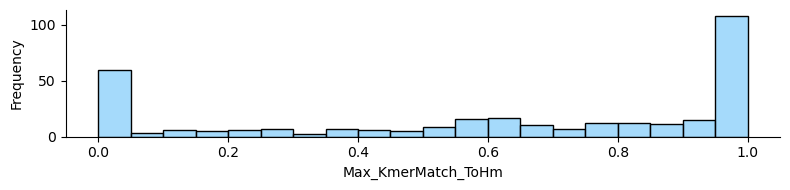

In [261]:
# Create a figure with 2 subplots stacked vertically
fig, ax1 = plt.subplots(1, 1, figsize=(8, 2))

# First subplot - Histogram
sns.histplot(GCE_AnnoByMatch_DF["Max_KmerMatch_ToHm"], bins=np.arange(0, 1.05, 0.05), color="#87CEFA", ax=ax1)
sns.despine(ax=ax1)
ax1.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Part 2: Classify sets of GC Events - Based on Paralog Mapping Results

In [262]:
GCE_All_DF = GCE_AnnoByMatch_DF
GCE_ABM_DF = GCE_AnnoByMatch_DF

# Seperate GC Event Info DF into GCEs WITH and WITHOUT paralogs
GCE_InPR_DF = GCE_All_DF.query("NumHmTargets > 0")
GCE_NotInPR_DF = GCE_All_DF.query("NumHmTargets == 0")

mGCE_DF = GCE_AnnoByMatch_DF.query("MappedEvent == True") #.query("Max_KmerMatch_ToHm >= 0.5")
GCE_Mapped_DF = mGCE_DF

GCE_NotMapped_DF = GCE_AnnoByMatch_DF.query("MappedEvent == False") #.query("Max_KmerMatch_ToHm < 0.5")

GCE_NotMapped_InPR_DF = GCE_NotMapped_DF.query("NumHmTargets > 0")

GCE_NotMapped_NotInPR_DF = GCE_NotMapped_DF.query("NumHmTargets == 0")


print("# of TOTAL detected events", GCE_All_DF.shape[0])

print("# of detected events IN a Paralog-Region:", GCE_InPR_DF.shape[0])
print("# of detected events NOT IN a Paralog-Region:", GCE_NotInPR_DF.shape[0])
print("")
print("# of mapped events", GCE_Mapped_DF.shape[0])
print("# of NOT MAPPED events:", GCE_NotMapped_DF.shape[0])

print("# of NOT MAPPED events IN a Paralog-Region:", GCE_NotMapped_InPR_DF.shape[0])


# of TOTAL detected events 324
# of detected events IN a Paralog-Region: 295
# of detected events NOT IN a Paralog-Region: 29

# of mapped events 217
# of NOT MAPPED events: 107
# of NOT MAPPED events IN a Paralog-Region: 78


In [263]:
### Step 1: Get list of all mapped GC EventIDs (Even if there are multiple high-match donors)

G_Filt_Kmatch_EventIDs = mGCE_DF["EventID"].values
print(len(G_Filt_Kmatch_EventIDs))


217


# Part 3: Distribute mapped events across homology-map (paralogous alignments)

In [264]:
Mtb_HM_Var_PR_SNPs_DF.head(4)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


### Get all TOP matches to paralogs for each GCE

In [265]:
mGCEToParalogs_TopKmerMatches_Info_DF = getEventKmerMatchInfo_TopParalogMatches(mGCE_DF,
                                                                                GCE_MatchToHmRegions_DF)

mGCEToParalogs_TopKmerMatches_Info_DF.shape

(248, 14)

### Distribute donor/acceptor counts across all PR-Regions

In [266]:
HmRegions_DonorAndEventCt_DF, Overall_DonorCountSum = distribute_mGCE_donor_acceptor_counts_UnqParalogRegions(HmMapRegs_ParaRegs_k19w19_DF,
                                                                                                              mGCE_DF,
                                                                                                              GCE_All_DF,
                                                                                                              Mtb_HM_Var_PR_SNPs_DF,
                                                                                                              mGCEToParalogs_TopKmerMatches_Info_DF)

print( HmRegions_DonorAndEventCt_DF.shape, Overall_DonorCountSum)

Overall_Donor_Count: 217.0
(200, 24) 217.0


In [267]:
HmRegions_DonorAndEventCt_DF.head(3) 

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,0.0,0,0,0.0,0.0,0.0,0.0,374,374
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.5,19,31,8.5,29.5,0.288136,0.612903,68,35


In [268]:
mGCEToParalogs_TopKmerMatches_Info_DF.head(1)

,EventID,start_0based,end_1based,Overlap_Genes,HomologTargetID,Hm_Overlap_Genes,Target_Start,Target_End,Total_SNPs,NumMatch_Kmers,Total_Kmers,P_KmerMatch,Dist_Event_To_Hm,seqname
0,Event_001,103599,104478,"Rv0093c,Rv0094c","Rv1587c,Rv1588c-H37Rv-1788513-1789865","Rv1587c,Rv1588c",1788513,1789865,10,68,79,0.8608,1685150.5,NC_000962.3


In [269]:
mGCEToParalogs_TopKmerMatches_Info_DF.query("Hm_Overlap_Genes == 'esxI,esxJ' ")

,EventID,start_0based,end_1based,Overlap_Genes,HomologTargetID,Hm_Overlap_Genes,Target_Start,Target_End,Total_SNPs,NumMatch_Kmers,Total_Kmers,P_KmerMatch,Dist_Event_To_Hm,seqname
88,Event_101,1340687,1340784,esxK,"esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",1160545,1161167,4,17,28,0.6071,179879.5,NC_000962.3
90,Event_102,1340915,1341073,"esxK,esxL","esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",1160545,1161167,6,34,64,0.5312,180138.0,NC_000962.3
92,Event_104,1341022,1341120,esxL,"esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",1160545,1161167,4,29,39,0.7436,180215.0,NC_000962.3
96,Event_107,1341031,1341254,esxL,"esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",1160545,1161167,4,34,34,1.0000,180286.5,NC_000962.3
98,Event_108,1341072,1341120,esxL,"esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",1160545,1161167,7,53,53,1.0000,180240.0,NC_000962.3
152,Event_171,2030486,2030521,esxM,"esxI,esxJ-H37Rv-1160538-1161165","esxI,esxJ",1160538,1161165,4,13,24,0.5417,869652.0,NC_000962.3
183,Event_213,2626510,2626521,esxP,"esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",1160545,1161167,4,14,21,0.6667,1465659.5,NC_000962.3
184,Event_214,2626510,2626521,esxP,"esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",1160545,1161167,4,14,21,0.6667,1465659.5,NC_000962.3
245,Event_322,4060099,4060230,esxV,"esxI,esxJ-H37Rv-1160543-1161151","esxI,esxJ",1160543,1161151,4,41,41,1.0000,1512214.5,NC_000962.3


# Part 4: Count # of events and donors for each homologous pair (in Rv genome)

## A) Calculate the normalized count of events per HmPair (pair of paralogous regions in genome)

In [270]:
HmPair_EventCt_DF, i_PerHmPair_EventCt_Dict = summarize_HmPair_MappedEvent_counts(
    in_HmPair_DF = HmMap_Aln_k19w19_NoOverlap_DF,
    in_Mapped_GCE_DF = mGCE_DF,
    in_Putative_GCE_DF = GCE_All_DF,
    in_mGCEToParalogs_TopKmerMatches_Info_DF = mGCEToParalogs_TopKmerMatches_Info_DF,
)

HmPair_EventCt_DF["Aln_N_SNPs"] = HmPair_EventCt_DF["cs"].apply(count_substitutions_in_cs)
HmPair_EventCt_DF["SNPs_Per1kb_Aln"] = HmPair_EventCt_DF["Aln_N_SNPs"] / HmPair_EventCt_DF["Aln_BlockLength"] * 1000

HmPair_EventCt_DF["QueryOverlap_Genes"]  = HmPair_EventCt_DF["QueryOverlap_Genes"].fillna("_")
HmPair_EventCt_DF["TargetOverlap_Genes"] = HmPair_EventCt_DF["TargetOverlap_Genes"].fillna("_")

# Count number of overlapping events
HmPair_EventCt_DF = bf.count_overlaps(HmPair_EventCt_DF,
                                         HmPair_EventCt_DF, 
                                         cols1 = ('Target_Name', 'Target_Start', 'Target_End'),
                                         cols2 = ('Target_Name', 'Target_Start', 'Target_End') ).rename(columns={'count': 'N_Ovrlap_ParalogAlns'})

HmPair_EventCt_DF["SeqID"] = HmPair_EventCt_DF["SeqID"].astype(float)
HmPair_EventCt_DF["N_Ovrlap_ParalogAlns"] = HmPair_EventCt_DF["N_Ovrlap_ParalogAlns"].astype(int)
HmPair_EventCt_DF["Dist"] = HmPair_EventCt_DF["Dist_Middles"]
HmPair_EventCt_DF["Distance_kb"] = HmPair_EventCt_DF["Dist"] / 1000

HmPair_EventCt_DF = calculate_gc_content_perwindow(H37Rv_Seq, HmPair_EventCt_DF)

HmPair_EventCt_DF.shape

Overall_Donor_Counts inferred across all paralog-pairs: 217.0


(640, 51)

In [271]:
#i_PerHmPair_EventCt_Dict["NC_000962.3:1160543-1161151;NC_000962.3:4059983-406059"]

In [272]:
HmPair_EventCt_DF.query("QueryToTarget_ID == 'NC_000962.3:1160543-1161151;NC_000962.3:4059983-4060591' ")

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
84,NC_000962.3,1160543,1161151,+,NC_000962.3,4059983,4060591,605.0,608.0,:485*gc:2*ag:115*tc:3,0.995066,4060287.0,1160847.0,1512092.0,608,608,"esxI,esxJ","esxV,esxW",False,False,0,0,NC_000962.3:1160543-1161151,NC_000962.3:4059983-4060591,NC_000962.3:1160543-1161151;NC_000962.3:405998...,41,1160538,1161167,186,4059983,4060591,PR_HmRegion_042,PR_HmRegion_189,42,189,0,0,PR_Set_28,1.0,"(1500000, 1550000]",1525000.0,"esxI,esxJ","esxV,esxW",0.052632,1,3,4.934211,4,1512092.0,1512.092,63.382594


In [273]:
HmPair_EventCt_DF.query("QueryToTarget_ID == 'NC_000962.3:4059983-4060591;NC_000962.3:1160543-1161151' ")

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
623,NC_000962.3,4059983,4060591,+,NC_000962.3,1160543,1161151,605.0,608.0,:485*cg:2*ga:115*ct:3,0.995066,1160847.0,4060287.0,1512092.0,608,608,"esxV,esxW","esxI,esxJ",False,False,0,0,NC_000962.3:4059983-4060591,NC_000962.3:1160543-1161151,NC_000962.3:4059983-4060591;NC_000962.3:116054...,186,4059983,4060591,41,1160538,1161167,PR_HmRegion_189,PR_HmRegion_042,189,42,0,0,PR_Set_28,0.0,"(1500000, 1550000]",1525000.0,"esxV,esxW","esxI,esxJ",0.0,0,3,4.934211,4,1512092.0,1512.092,63.546798


In [274]:
HmPair_EventCt_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.0,0,374,181.729835,1,1609866.0,1609.8660,65.328110


In [275]:
HmPair_EventCt_DF.tail(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
638,NC_000962.3,4320044,4320106,+,NC_000962.3,4077792,4077854,62.0,62.0,:62,1.00,4077823.0,4320075.0,242252.0,62,62,_,_,False,True,0,0,NC_000962.3:4320044-4320106,NC_000962.3:4077792-4077854,NC_000962.3:4320044-4320106;NC_000962.3:407779...,195,4320044,4320106,188,4077792,4078201,PR_HmRegion_198,PR_HmRegion_191,198,191,0,0,PR_Set_5,0.0,"(200000, 250000]",225000.0,_,_,0.0,0,0,0.000000,2,242252.0,242.252,50.793651
639,NC_000962.3,4383094,4383754,-,NC_000962.3,2341059,2341697,513.0,675.0,:11*ag:16*ct:2*ga*ca:14*ct:6*ag:7*gc*gc:1*ga:2...,0.76,2341378.0,4383424.0,2042046.0,660,638,"Rv3897c,Rv3898c",Rv2083,False,False,0,0,NC_000962.3:4383094-4383754,NC_000962.3:2341059-2341697,NC_000962.3:4383094-4383754;NC_000962.3:234105...,196,4383094,4383754,100,2341059,2341697,PR_HmRegion_199,PR_HmRegion_102,199,102,0,0,PR_Set_53,0.0,"(2000000, 2050000]",2025000.0,"Rv3897c,Rv3898c",Rv2083,0.0,0,110,162.962963,1,2042046.0,2042.046,73.708920


In [276]:
HmPair_EventCt_DF["PR_SetID"].nunique()

70

In [277]:
HmRegions_DonorAndEventCt_DF["PR_SetID"].nunique()

70

# Overview of processed info:

In [278]:
GCE_AnnoByMatch_DF[ GCE_AnnoByMatch_DF["Overlap_Genes"].str.contains("PPE18") ].head(1)  


,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent
90,NC_000962.3,1339399,1339436,.,Node_36,Node_28,655.459143,4,"[M0016395_7, R15311]",1339398,1339417.0,38,lineage4,2,PPE18,Rv1196,Event_091,False,True,False,False,PR_HmRegion_053,2,1,0,0,0,0,1,1,2,False,0.25,2,2,"PPE19-H37Rv-1532539-1533632-PE31,PPE60-H37Rv-3...","PPE19-PE31,PPE60",0.5769,NaN,26,2,"PPE19-H37Rv-1532539-1533632-PE31,PPE60-H37Rv-3...","PPE19-PE31,PPE60",0.75,NaN,True


### a) RecombEvents annotated by their best match

In [279]:
GCE_AnnoByMatch_DF.query("EventID == 'Event_113'")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent
112,NC_000962.3,1533159,1533241,.,Node_26,Node_25,379.338694,5,"[M0017522_5, S0106-01, R21770, R21839, R21363,...",1533158,1533199.5,83,lineage4,8,PPE19,Rv1361c,Event_113,False,True,False,False,PR_HmRegion_060,2,1,0,0,0,0,1,1,8,False,0.4,2,1,PPE18-H37Rv-1339349-1340433,PPE18,1.0,193308.5,32,1,PPE18-H37Rv-1339349-1340433,PPE18,0.8,193308.5,True


### b) DF for each RecombEvent to ALL homologs

In [280]:
GCE_MatchToHmRegions_DF.query("EventID == 'Event_113'").head(2)

,EventID,start_0based,end_1based,Overlap_Genes,HomologTargetID,Hm_Overlap_Genes,Target_Start,Target_End,NumMatch_SNPs,Total_SNPs,P_SNPMatch,NumMatch_Kmers,Total_Kmers,P_KmerMatch,Dist_Event_To_Hm
220,Event_113,1533158,1533241,PPE19,PPE18-H37Rv-1339349-1340433,PPE18,1339349,1340433,4,5,0.8,32,32,1.0,193308.5
221,Event_113,1533158,1533241,PPE19,PPE60-H37Rv-3894405-3895588,PPE60,3894405,3895588,2,5,0.4,0,32,0.0,2049735.0


### c) Dict of k-mer match info for each event & homolog pair

In [281]:
GCE_EventMap_KmerAnalysisDict["Event_113"].keys()  

dict_keys(['Ancestral_Seq', 'PPE18-H37Rv-1339349-1340433', 'PPE60-H37Rv-3894405-3895588'])

In [282]:
GCE_EventMap_KmerAnalysisDict["Event_094"].keys()

dict_keys(['Ancestral_Seq', 'PPE19-H37Rv-1532539-1533632', 'PE31,PPE60-H37Rv-3894016-3895519'])

### d) Tables of mapped GC Events `per paralog-pair` and `per paralog-region`

In [283]:
HmPair_EventCt_DF.shape

(640, 51)

In [284]:
HmRegions_DonorAndEventCt_DF.shape

(200, 24)

In [285]:
HmPair_EventCt_DF.head(3)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.000000,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.000000,0,374,181.729835,1,1609866.0,1609.8660,65.328110
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3,8.0,"(600000, 650000]",625000.0,"Rv0094c,Rv0095c","Rv3466,Rv3467",0.421053,17,35,25.179856,2,631701.5,631.7015,67.123288


In [286]:
HmRegions_DonorAndEventCt_DF.head(3)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,0.0,0,0,0.0,0.0,0.0,0.0,374,374
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.5,19,31,8.5,29.5,0.288136,0.612903,68,35


# Output RecombEvent-HmRegion Comparison DFs (TSV, Pickle)

In [287]:
print(Target_Output_Dir)

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10


In [1]:
RecombEvent_To_HmRegion_CompDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"
!mkdir $RecombEvent_To_HmRegion_CompDir

EventMapping_ResultsDir = RecombEvent_To_HmRegion_CompDir


GRE_Anno_ByTopHomologMatch_TSV = f"{RecombEvent_To_HmRegion_CompDir}/GubbinsEvents.WiParalogMapping.V1.tsv"

EventToAllParalogs_Info_TSV_PATH = f"{RecombEvent_To_HmRegion_CompDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"

Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{RecombEvent_To_HmRegion_CompDir}/EventMapping.DictOf.KmerComparisons.pickle"   


HmPairs_MappedEvents_TSV   = f"{RecombEvent_To_HmRegion_CompDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"
HmRegions_MappedEvents_TSV = f"{RecombEvent_To_HmRegion_CompDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"



NameError: name 'Target_Output_Dir' is not defined

#### a) Output Gubbins_RE_AnnoByMatch_DF as TSV

In [289]:
GCE_AnnoByMatch_DF.to_csv(GRE_Anno_ByTopHomologMatch_TSV,
                          sep = "\t",
                          index = False)

#### b) Output RE_MatchToHmRegions_DF as TSV

In [290]:
GCE_MatchToHmRegions_DF.to_csv(EventToAllParalogs_Info_TSV_PATH, sep = "\t", index = False)

### c) Output `dictOf_FullKmerAnalysis_PerEvent` as Pickle (PKL)

In [291]:
with open(Pickle_PATH_dictOf_EventAndHomolog_KmerComp, 'wb') as outputFile:
    
    pickle.dump(GCE_EventMap_KmerAnalysisDict, outputFile)


#### Peak at the output directory

In [292]:
!ls -lah $RecombEvent_To_HmRegion_CompDir

total 14M
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  4 09:03 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:36 ..
-rw-r--r-- 1 mm774 hpc_farhat  13M Dec 14 14:40 EventMapping.DictOf.KmerComparisons.pickle
-rw-r--r-- 1 mm774 hpc_farhat  72K Dec 14 14:40 EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv
-rw-r--r-- 1 mm774 hpc_farhat  26K Dec 14 14:37 GCE.Stats.PerMergedHmRegion.PRs.tsv
-rw-r--r-- 1 mm774 hpc_farhat 591K Dec 14 14:37 GCE.Stats.PerPairwiseAln.PRs.tsv
-rw-r--r-- 1 mm774 hpc_farhat 132K Dec 14 14:40 GubbinsEvents.WiParalogMapping.V1.tsv


# Output MAPPED events count to PR-Pairs and PR-Regions to TSV

In [293]:
HmPair_EventCt_DF.to_csv(HmPairs_MappedEvents_TSV, sep="\t", index=False)
HmRegions_DonorAndEventCt_DF.to_csv(HmRegions_MappedEvents_TSV, sep="\t", index=False)


In [294]:
!wc -l $HmPairs_MappedEvents_TSV

641 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/RecombEvent-To-HmRegion-Comparison-V3/GCE.Stats.PerPairwiseAln.PRs.tsv


In [295]:
!wc -l $HmRegions_MappedEvents_TSV

201 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/RecombEvent-To-HmRegion-Comparison-V3/GCE.Stats.PerMergedHmRegion.PRs.tsv


In [296]:
!ls -lah $EventMapping_ResultsDir

total 14M
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  4 09:03 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec  9 10:36 ..
-rw-r--r-- 1 mm774 hpc_farhat  13M Dec 14 14:40 EventMapping.DictOf.KmerComparisons.pickle
-rw-r--r-- 1 mm774 hpc_farhat  72K Dec 14 14:40 EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv
-rw-r--r-- 1 mm774 hpc_farhat  26K Dec 14 14:40 GCE.Stats.PerMergedHmRegion.PRs.tsv
-rw-r--r-- 1 mm774 hpc_farhat 591K Dec 14 14:40 GCE.Stats.PerPairwiseAln.PRs.tsv
-rw-r--r-- 1 mm774 hpc_farhat 132K Dec 14 14:40 GubbinsEvents.WiParalogMapping.V1.tsv


## Test reparsing the processed data from this notebook

In [297]:
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"
HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"

HmPair_EventCt_DF = pd.read_csv(HmPairs_MappedEvents_TSV, sep = "\t")

HmRegions_DonorAndEventCt_DF = pd.read_csv(HmRegions_MappedEvents_TSV, sep = "\t")


In [298]:
HmPair_EventCt_NoPerf_DF = HmPair_EventCt_DF.query("SeqID < 100")

HmPair_EventsOnly_DF = HmPair_EventCt_NoPerf_DF.query("EventsMapped > 0")


In [299]:
print(HmPair_EventCt_DF.shape)
print(HmPair_EventCt_NoPerf_DF.shape)
print(HmPair_EventsOnly_DF.shape)


(640, 51)
(640, 51)
(69, 51)


# Extra testing and exploration

# Create`H37Rv` Paralog Network Graphs 

## Build graphs of H37Rv paralog sets

In [300]:
RegionNum_To_Genes_Dict = dict(HmRegions_DonorAndEventCt_DF[['HmRegion_Num', 'Overlap_Genes']].values)

In [301]:
HmPair_EventCt_DF.head(1)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295


In [302]:
HmPair_EventCt_DF.shape

(640, 51)

### Create graph object (bi-directional) of ALL Hm-Pairs

In [303]:
Mtb_PR_Sets_All_graph = CreatePR_DiGraph(HmRegions_DonorAndEventCt_DF,
                                         HmPair_EventCt_DF,
                                         edge_keep_mode = 'keep_all')

# Define ParalogRegion Sets (PR-Sets) based on the homology map graph
pr_set_dict, pr_set_df = infer_HmMap_ParalogSet_Labels(Mtb_PR_Sets_All_graph)


### Create graph object (bi-directional) of mapped EVENT COUNTs between Hm-Pairs

In [304]:
Mtb_PR_Sets_mGCE_Ct_graph = CreatePR_DiGraph(HmRegions_DonorAndEventCt_DF,
                                             HmPair_EventCt_DF,
                                             edge_keep_mode = 'keep_edges_Mapped_GCE')


### Create graph object (bi-directional) of putative EVENT COUNTs between Hm-Pairs

In [305]:
Mtb_PR_Sets_pGCE_Ct_graph = CreatePR_DiGraph(HmRegions_DonorAndEventCt_DF,
                                                  HmPair_EventCt_DF,
                                                  edge_keep_mode = 'keep_edges_Any_GCE')


In [306]:
AllPRs_DiGraph_Stats_Dict, AllPRs_DiGraph_Stats_DF = summarize_graph_stats(Mtb_PR_Sets_All_graph)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {AllPRs_DiGraph_Stats_Dict[k]}")
    

num_nodes: 200
num_edges: 543
num_connected_components: 70


In [307]:
pGCE_DiGraph_Stats_Dict, pGCE_DiGraph_Stats_DF = summarize_graph_stats(Mtb_PR_Sets_pGCE_Ct_graph)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {pGCE_DiGraph_Stats_Dict[k]}")
    

num_nodes: 68
num_edges: 96
num_connected_components: 24


In [308]:
mGCE_DiGraph_Stats_Dict, mGCE_DiGraph_Stats_DF = summarize_graph_stats(Mtb_PR_Sets_mGCE_Ct_graph)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {mGCE_DiGraph_Stats_Dict[k]}")
    

num_nodes: 52
num_edges: 65
num_connected_components: 21


In [309]:
HmRegions_DonorAndEventCt_DF.query("PR_SetID == 'PR_Set_3' ")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.5,19,31,8.5,29.5,0.288136,0.612903,68,35
74,74,NC_000962.3,1788513,1789865,1789189.0,1352,"Rv1587c,Rv1588c",0,2,2,1,74,PR_HmRegion_074,0,PR_Set_3,11.5,8,10,-3.5,19.5,-0.179487,0.800000,35,35
180,180,NC_000962.3,3883535,3884921,3884228.0,1386,"Rv3466,Rv3467",0,2,2,1,180,PR_HmRegion_180,0,PR_Set_3,13.0,8,17,-5.0,21.0,-0.238095,0.470588,37,35


In [310]:
HmRegions_DonorAndEventCt_DF.query("PR_SetID == 'PR_Set_23' ")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
31,31,NC_000962.3,835775,836519,836147.0,744,PE_PGRS9,0,2,2,2,31,PR_HmRegion_031,0,PR_Set_23,0.0,0,0,0.0,0.0,0.000000,0.000000,201,145
64,64,NC_000962.3,1633310,1634790,1634050.0,1480,PE_PGRS27,0,2,2,2,64,PR_HmRegion_064,0,PR_Set_23,19.0,14,19,-5.0,33.0,-0.151515,0.736842,184,184
65,65,NC_000962.3,1636705,1639561,1638133.0,2856,"PE_PGRS28,Rv1453",0,3,3,3,65,PR_HmRegion_065,0,PR_Set_23,14.0,19,21,5.0,33.0,0.151515,0.904762,429,424
117,117,NC_000962.3,2650377,2651923,2651150.0,1546,"Rv2370c,PE_PGRS40",0,1,1,1,117,PR_HmRegion_117,0,PR_Set_23,0.0,0,0,0.0,0.0,0.000000,0.000000,328,328


In [311]:
HmRegions_DonorAndEventCt_DF.query("PR_SetID == 'PR_Set_36' ")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
53,53,NC_000962.3,1338923,1340433,1339678.0,1510,"PE13,PPE18",0,2,2,2,53,PR_HmRegion_053,0,PR_Set_36,6.0,7,7,1.0,13.0,0.076923,1.0,240,196
60,60,NC_000962.3,1532461,1533653,1533057.0,1192,PPE19,0,2,2,2,60,PR_HmRegion_060,0,PR_Set_36,7.5,5,5,-2.5,12.5,-0.200000,1.0,151,130
182,182,NC_000962.3,3894016,3895588,3894802.0,1572,"PE31,PPE60",0,2,2,2,182,PR_HmRegion_182,0,PR_Set_36,6.5,8,8,1.5,14.5,0.103448,1.0,249,210


### Create graph object (uni-directional)

In [312]:
# pGCE_UniGraph = CreatePR_UGraph(HmRegions_DonorAndEventCt_DF,
#                                 HmPair_EventCt_DF,
#                                 edge_keep_mode = "keep_edges_Any_GCE")

In [313]:
# pGCE_UniGraph_Stats_Dict, pGCE_UniGraph_Stats_DF = summarize_graph_stats(pGCE_UniGraph)
# pGCE_UniGraph_Stats_DF.shape

In [314]:
# mGCE_UniGraph = CreatePR_UGraph(HmRegions_DonorAndEventCt_DF,
#                                 HmPair_EventCt_DF,
#                                 edge_keep_mode = "keep_edges_Mapped_GCE")

In [315]:
# mGCE_UniGraph_Stats_Dict, mGCE_UniGraph_Stats_DF = summarize_graph_stats(mGCE_UniGraph)
# mGCE_UniGraph_Stats_DF.shape

In [316]:
# mGCE_UniGraph_Stats_DF.head(3)

# Generate Paralog-Map Graph Visualizations (Non-directed)

## Viz pGCE RPS Network

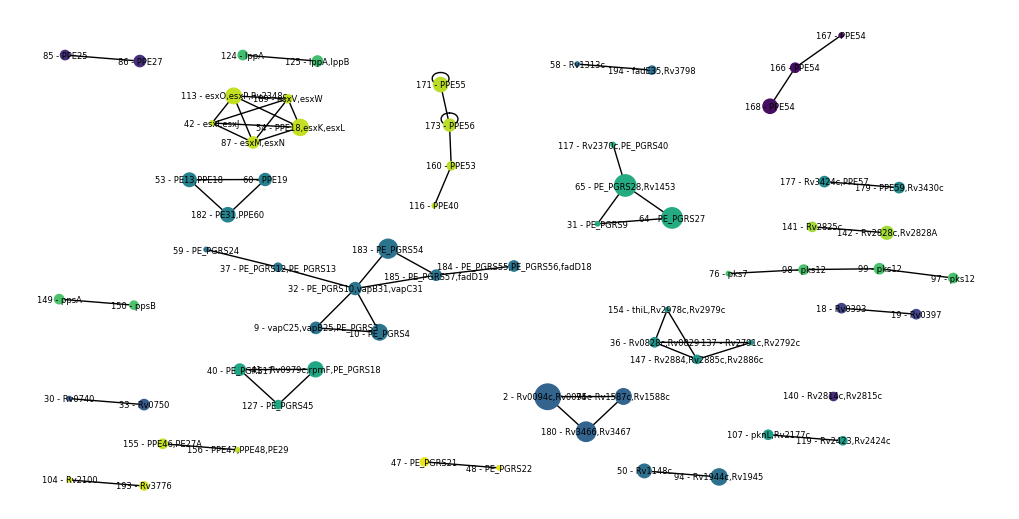

In [317]:
import networkx as nx
import matplotlib.pyplot as plt
import random

plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = Mtb_PR_Sets_pGCE_Ct_graph
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

node_sizes_mGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_mGCE.values()]
node_sizes_pGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_pGCE.values()]

# Color nodes the same in each connected subgraph
C = (in_Paralog_Graph.subgraph(c) for c in nx.connected_components(in_Paralog_Graph))
for g in C:
    c = [random.random()] * nx.number_of_nodes(g)  # Random color...
    nx.draw(
        g, pos,
        node_size = [node_sizes_pGCE[list(in_Paralog_Graph.nodes()).index(n)] for n in g.nodes()],  # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=True, font_size=6
    )

#plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.All.NX.V1.svg")
plt.show()


## Viz mGCE RPS Network

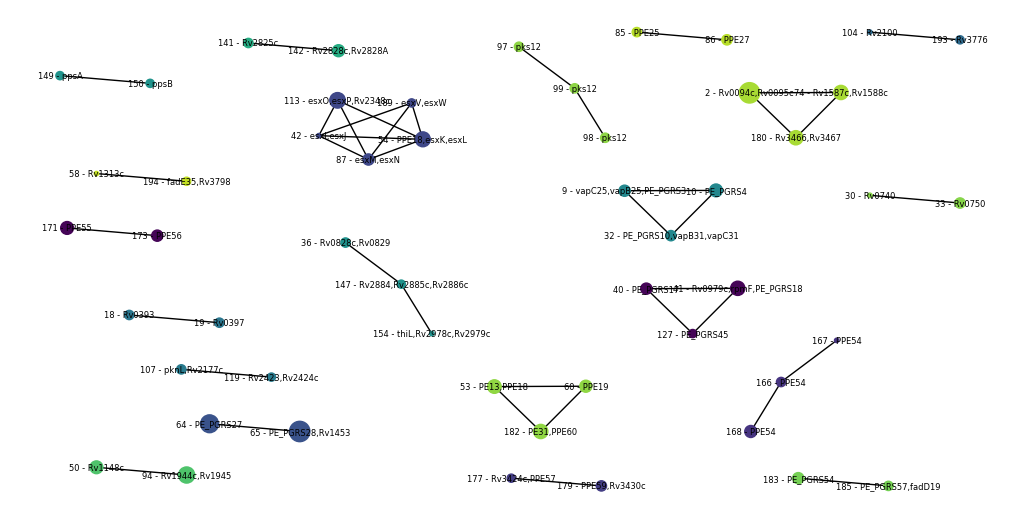

In [318]:
import networkx as nx
import matplotlib.pyplot as plt
import random

plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = Mtb_PR_Sets_mGCE_Ct_graph
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

node_sizes_mGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_mGCE.values()]
node_sizes_pGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_pGCE.values()]

# Color nodes the same in each connected subgraph
C = (in_Paralog_Graph.subgraph(c) for c in nx.connected_components(in_Paralog_Graph))
for g in C:
    c = [random.random()] * nx.number_of_nodes(g)  # Random color...
    nx.draw(
        g, pos,
        node_size = [node_sizes_mGCE[list(in_Paralog_Graph.nodes()).index(n)] for n in g.nodes()],  # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=True, font_size=6
    )

#plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.All.NX.V1.svg")
plt.show()


## Viz mGCE RPS Network (No Labels)

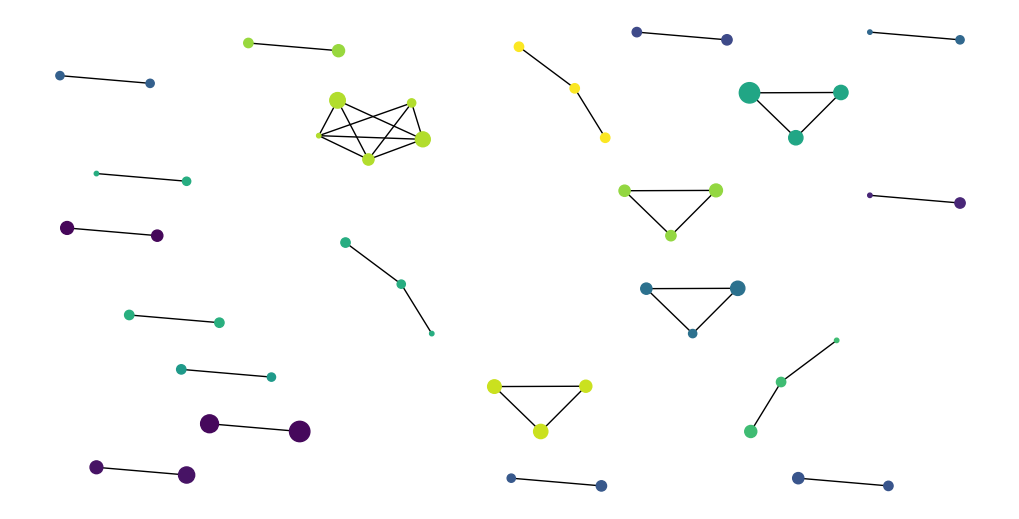

In [319]:
plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = Mtb_PR_Sets_mGCE_Ct_graph
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')
#pos = nx.spring_layout(G, k=0.5, scale=1)  # Larger scale = longer edges

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

node_sizes_mGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_mGCE.values()]
node_sizes_pGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_pGCE.values()]


C = (in_Paralog_Graph.subgraph(c) for c in nx.connected_components(in_Paralog_Graph))

for g in C:
    c = [random.random()] * nx.number_of_nodes(g)  # Random color...
    nx.draw(
        g, pos,
        node_size=[node_sizes_mGCE[list(in_Paralog_Graph.nodes()).index(n)] for n in g.nodes()],  # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=False, font_size=6
    )
    
# plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.All.NX.NoLabels.V1.svg")


## Viz COMPLETE H37Rv Paralog Network (No Labels)

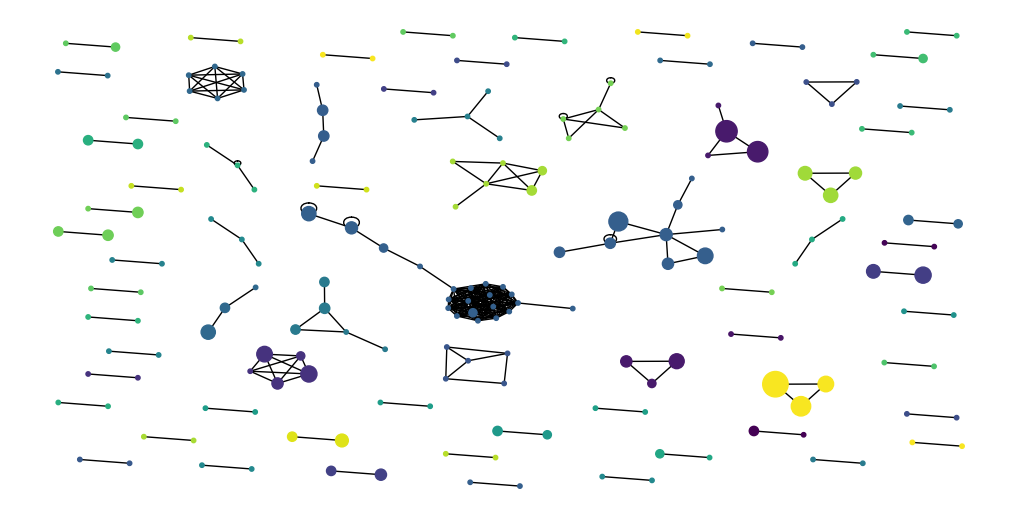

In [320]:
plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = Mtb_PR_Sets_All_graph
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')
#pos = nx.spring_layout(G, k=0.5, scale=1)  # Larger scale = longer edges

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

node_sizes_mGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_mGCE.values()]
node_sizes_pGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_pGCE.values()]

C = (in_Paralog_Graph.subgraph(c) for c in nx.connected_components(in_Paralog_Graph))

for g in C:
    c = [random.random()] * nx.number_of_nodes(g)  # Random color...
    nx.draw(
        g, pos,
        node_size=[node_sizes_pGCE[list(in_Paralog_Graph.nodes()).index(n)] for n in g.nodes()],  # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=False, font_size=6
    )
    
# plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.All.NX.NoLabels.V1.svg")


## Viz COMPLETE H37Rv Paralog Network (W/ Labels)

/tmp/ipykernel_226262/1573334349.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


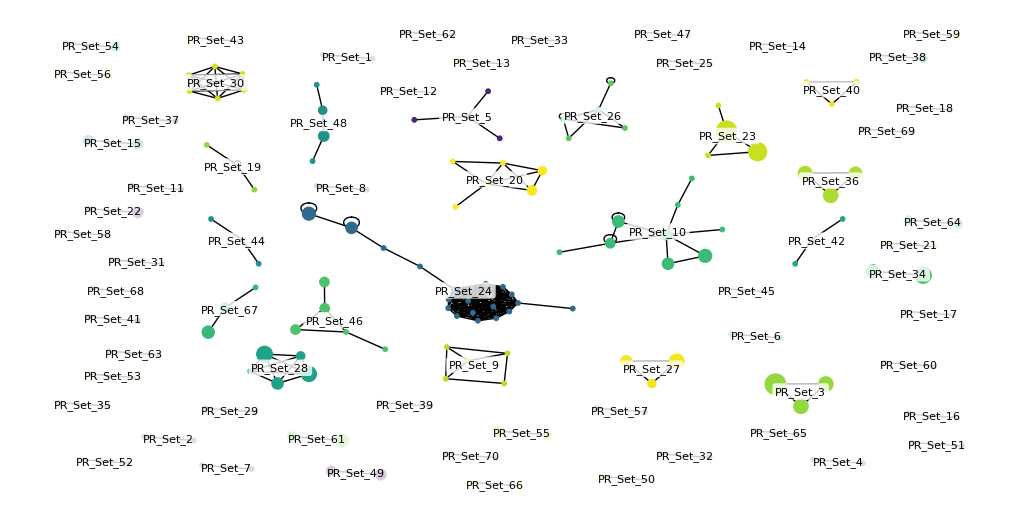

In [321]:
import random
import numpy as np
import matplotlib.pyplot as plt

plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = Mtb_PR_Sets_All_graph
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

# Keep node order list so we can index consistently
all_nodes = list(in_Paralog_Graph.nodes())

node_sizes_mGCE = [
    25 + (event_counts_mGCE.get(n, 0) * 10) if event_counts_mGCE.get(n, 0) > 0 else 10
    for n in all_nodes
]

# Iterate over connected components
for comp_nodes in nx.connected_components(in_Paralog_Graph):
    g = in_Paralog_Graph.subgraph(comp_nodes)

    # Random color per component
    c = [random.random()] * nx.number_of_nodes(g)

    # Node sizes for this component (mapped from global order)
    comp_node_sizes = [
        node_sizes_mGCE[all_nodes.index(n)]
        for n in g.nodes()
    ]

    nx.draw(
        g, pos,
        node_size=comp_node_sizes,   # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=False, font_size=6
    )

    # ---------- Add PR_SetID label per component ----------
    # Collect PR_SetID values for nodes in this component
    pr_ids = {
        in_Paralog_Graph.nodes[n].get("PR_SetID")
        for n in g.nodes()
    }
    # Expecting exactly one, but fall back if not
    if len(pr_ids) == 1:
        comp_label = next(iter(pr_ids))
    else:
        # e.g. if missing or mixed, just show all or use a generic label
        comp_label = ", ".join(sorted(str(x) for x in pr_ids if x is not None)) or "Unlabeled"

    # Compute centroid of node positions in this component
    xs = [pos[n][0] for n in g.nodes()]
    ys = [pos[n][1] for n in g.nodes()]
    x_center = np.mean(xs)
    y_center = np.mean(ys)

    # Draw the label at the centroid
    plt.text(
        x_center, y_center,
        comp_label,
        ha="center", va="center",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25",
                  fc="white", ec="none", alpha=0.8)
    )

plt.axis("off")
plt.tight_layout()
plt.show()


In [322]:
#event_counts_pGCE

In [323]:
#event_counts_mGCE

## Build H37Rv ParalogRegion Graph - ONLY use NON-Perfect repeats

In [324]:
HmMap_Aln_k19w19_NoOverlap_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2


In [325]:
HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1").shape

(255, 38)

In [326]:
HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID < 1").shape

(385, 38)

In [327]:
Rv_PR_NonPerf_graph = CreatePR_DiGraph(HmMapRegs_ParaRegs_k19w19_DF,
                                       HmPair_EventCt_DF.query("SeqID < 1"),
                                       edge_keep_mode='keep_all')


# Define ParalogRegion Sets (PR-Sets) based on the homology map graph
Rv_PR_NonPerf_dict, Rv_PR_NonPerf_df = infer_HmMap_ParalogSet_Labels(Rv_PR_NonPerf_graph)

# Add Paralog Set IDs to nodes within the graph
Rv_PR_NonPerf_graph = add_PR_SetID_to_graph(Rv_PR_NonPerf_graph, Rv_PR_NonPerf_dict)

In [328]:
Rv_PR_NonPerf_G_stats_dict, Rv_PR_NonPerf_G_stats_df = summarize_graph_stats(Rv_PR_NonPerf_graph)
print(Rv_PR_NonPerf_G_stats_df.shape)

(65, 2)


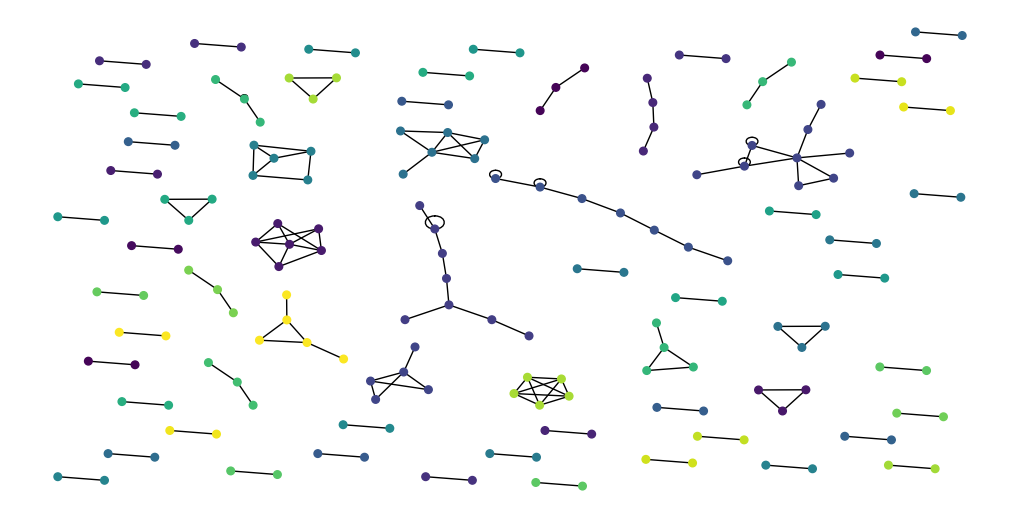

In [329]:
plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = Rv_PR_NonPerf_graph

in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')
#pos = nx.spring_layout(G, k=0.5, scale=1)  # Larger scale = longer edges

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

node_sizes_mGCE = [25 + (v * 10) if v > 0 else 30 for v in event_counts_mGCE.values()]
node_sizes_pGCE = [25 + (v * 10) if v > 0 else 30 for v in event_counts_pGCE.values()]

C = (in_Paralog_Graph.subgraph(c) for c in nx.connected_components(in_Paralog_Graph))

for g in C:
    c = [random.random()] * nx.number_of_nodes(g)  # Random color...
    nx.draw(
        g, pos,
        node_size=[node_sizes_mGCE[list(in_Paralog_Graph.nodes()).index(n)] for n in g.nodes()],  # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=False, font_size=6
    )
    
# plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.All.NX.NoLabels.V1.svg")


### Make a reference set of node sizes

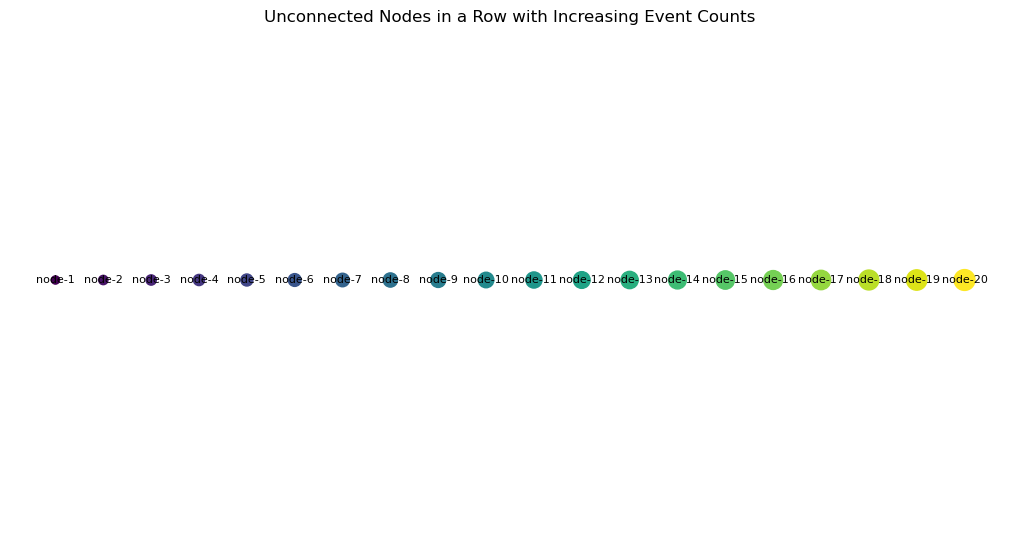

In [330]:
import numpy as np

# Create an empty graph
RefSizes_G = nx.Graph()

# Number of nodes to add
num_nodes = 20

# Add unconnected nodes with increasing eventcounts

pos = {}

for i in range(1, num_nodes + 1):
    CT = i
    node_name = f"node-{i}"
    
    pos[node_name] = (i, 0)
    
    RefSizes_G.add_node(node_name, counts_mGCE=i)

# Extract event counts for node sizes
event_counts = nx.get_node_attributes(RefSizes_G, "counts_mGCE")
node_sizes = [25 + (v * 10) for v in event_counts.values()]  # Scale by event counts

node_sizes = [25 + (v * 10) if v > 0 else 30 for v in event_counts.values()]

# Arrange nodes in a row from left to right
pos = {f"node-{i}": (i, 0) for i in range(1, num_nodes + 1)}

# Plot the graph
plt.figure(1, figsize=(10, 5))
nx.draw(RefSizes_G, pos, 
    node_size=node_sizes, 
    node_color=list(event_counts.values()),  # Color by eventcounts
    cmap=plt.cm.viridis,
    with_labels=True, 
    font_size=8)

plt.title("Unconnected Nodes in a Row with Increasing Event Counts")
plt.show()


# Exploration of Paralog Network 10

In [331]:
PN10_OG_SubG = subset_graph_by_PR_SetIDs(Mtb_PR_Sets_All_graph, ["PR_Set_10"])


In [332]:
summarize_graph_stats(PN10_OG_SubG)

({'num_nodes': 9,
  'num_edges': 22,
  'is_directed': True,
  'num_connected_components': 1,
  'connected_component_sizes': [9],
  'degree_min': 2.0,
  'degree_max': 12.0,
  'degree_mean': 4.888888888888889,
  'degree_median': 4.0,
  'edge_weight_min': 0.0,
  'edge_weight_max': 6.0,
  'edge_weight_mean': 0.5909090909090909,
  'edge_weight_median': 0.0,
  'num_weak_components': 1,
  'num_strong_components': 1},
   ComponentID  NumNodes
 0      Comp_1         9)

In [333]:
HmRegions_DonorAndEventCt_DF.query("PR_SetID == 'PR_Set_10' ")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
9,9,NC_000962.3,332698,336379,334538.5,3681,"vapC25,vapB25,PE_PGRS3",0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10,8.0,4,4,-4.0,12.0,-0.333333,1.000000,960,838
10,10,NC_000962.3,336565,339142,337853.5,2577,PE_PGRS4,0,2,2,2,10,PR_HmRegion_010,0,PR_Set_10,2.0,6,10,4.0,8.0,0.500000,0.600000,732,629
32,32,NC_000962.3,838485,841665,840075.0,3180,"PE_PGRS10,vapB31,vapC31",0,8,8,8,32,PR_HmRegion_032,0,PR_Set_10,3.0,3,5,0.0,6.0,0.000000,0.600000,2272,1272
37,37,NC_000962.3,925071,927514,926292.5,2443,"PE_PGRS12,PE_PGRS13",0,3,3,3,37,PR_HmRegion_037,0,PR_Set_10,0.0,0,1,0.0,0.0,0.000000,0.000000,868,582
59,59,NC_000962.3,1489087,1489833,1489460.0,746,PE_PGRS24,0,1,1,1,59,PR_HmRegion_059,0,PR_Set_10,0.0,0,0,0.0,0.0,0.000000,0.000000,153,153
176,176,NC_000962.3,3802143,3802720,3802431.5,577,PE_PGRS52,0,1,1,1,176,PR_HmRegion_176,0,PR_Set_10,0.0,0,0,0.0,0.0,0.000000,0.000000,81,81
183,183,NC_000962.3,3930988,3936438,3933713.0,5450,PE_PGRS54,0,6,6,6,183,PR_HmRegion_183,0,PR_Set_10,3.0,4,16,1.0,7.0,0.142857,0.250000,1705,1336
184,184,NC_000962.3,3941407,3945597,3943502.0,4190,"PE_PGRS55,PE_PGRS56,fadD18",0,1,1,1,184,PR_HmRegion_184,0,PR_Set_10,0.0,0,3,0.0,0.0,0.000000,0.000000,614,614
185,185,NC_000962.3,3945777,3951329,3948553.0,5552,"PE_PGRS57,fadD19",0,4,4,4,185,PR_HmRegion_185,0,PR_Set_10,3.0,2,3,-1.0,5.0,-0.200000,0.666667,1416,1276


In [334]:
HmPair_EventCt_DF.query("PR_SetID == 'PR_Set_10' ")

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
12,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",0.105263,5,433,116.304056,9,505588.5,505.5885,75.699466
13,NC_000962.3,333510,336379,+,NC_000962.3,336565,339142,2150.0,2933.0,:9*ct:13*tg*gc:1*tg:8*tc:12*ga:5*tc:3*cg:1*gc:...,0.733038,337853.5,334944.5,2909.0,2869,2577,PE_PGRS3,PE_PGRS4,False,False,0,0,NC_000962.3:333510-336379,NC_000962.3:336565-339142,NC_000962.3:333510-336379;NC_000962.3:336565-3...,9,332698,336379,10,336565,339142,PR_HmRegion_009,PR_HmRegion_010,9,10,0,0,PR_Set_10,6.0,"(0, 50000]",25000.0,PE_PGRS3,PE_PGRS4,0.315789,10,363,123.764064,2,2909.0,2.9090,77.269201
14,NC_000962.3,333603,336275,-,NC_000962.3,838485,840727,1806.0,2771.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.651750,839606.0,334939.0,504667.0,2672,2242,PE_PGRS3,PE_PGRS10,False,False,0,0,NC_000962.3:333603-336275,NC_000962.3:838485-840727,NC_000962.3:333603-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.000000,3,337,121.616745,9,504667.0,504.6670,79.402586
15,NC_000962.3,334966,335983,-,NC_000962.3,839656,840754,786.0,1165.0,:8*tc:3*ct:23*ag:1*tc:2*gc:2*gc:8*tc*ga:1*ct:5...,0.674678,840205.0,335474.5,504730.5,1017,1098,PE_PGRS3,PE_PGRS10,False,False,0,0,NC_000962.3:334966-335983,NC_000962.3:839656-840754,NC_000962.3:334966-335983;NC_000962.3:839656-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.000000,0,164,140.772532,8,504730.5,504.7305,81.164695
16,NC_000962.3,336565,339038,-,NC_000962.3,838485,840847,1736.0,2732.0,:3*ga:6*ga:7*ga:2*gc*ga:1*gt*ac:3*ga:4+a:2-g:2...,0.635432,839666.0,337801.5,501864.5,2473,2362,PE_PGRS4,PE_PGRS10,False,False,0,0,NC_000962.3:336565-339038,NC_000962.3:838485-840847,NC_000962.3:336565-339038;NC_000962.3:838485-8...,10,336565,339142,31,838485,841665,PR_HmRegion_010,PR_HmRegion_032,10,32,0,0,PR_Set_10,1.0,"(500000, 550000]",525000.0,PE_PGRS4,PE_PGRS10,0.052632,3,367,134.333821,9,501864.5,501.8645,79.263648
17,NC_000962.3,336565,339142,+,NC_000962.3,333510,336379,2150.0,2933.0,:9*tc:13*gt*cg:1*gt:8*ct:12*ag:5*ct:3*gc:1*cg:...,0.733038,334944.5,337853.5,2909.0,2577,2869,PE_PGRS4,PE_PGRS3,False,False,0,0,NC_000962.3:336565-339142,NC_000962.3:333510-336379,NC_000962.3:336565-339142;NC_000962.3:333510-3...,10,336565,339142,9,332698,336379,PR_HmRegion_010,PR_HmRegion_009,10,9,0,0,PR_Set_10,1.0,"(0, 50000]",25000.0,PE_PGRS4,PE_PGRS3,0.052632,1,363,123.764064,3,2909.0,2.9090,77.108014
39,NC_000962.3,838485,840847,-,NC_000962.3,336565,339038,1734.0,2732.0,:6*gc:11*ga:4*tg*gc:1*tg:8*tc:2*tc:9+gccgctggg...,0.634700,337801.5,839666.0,501864.5,2362,2473,PE_PGRS10,PE_PGRS4,False,False,0,0,NC_000962.

### Viz OG `ParalogNetwork-10`

/tmp/ipykernel_226262/2566948735.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


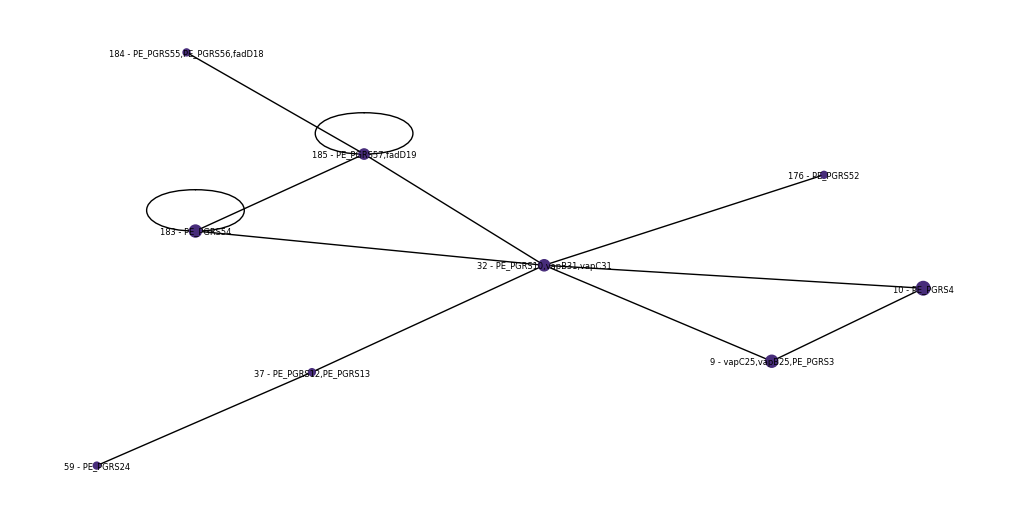

In [335]:
plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = PN10_OG_SubG
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Remove nodes with counts_pGCE <= 0 (or missing)
# nodes_to_keep = [
#     n for n, d in in_Paralog_Graph.nodes(data=True)
#     if d.get("counts_pGCE", 0) > 0
# ]

# in_Paralog_Graph = in_Paralog_Graph.subgraph(nodes_to_keep).copy()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

# Keep node order list so we can index consistently
all_nodes = list(in_Paralog_Graph.nodes())

node_sizes_mGCE = [
    35 + (event_counts_mGCE.get(n, 0) * 10) if event_counts_mGCE.get(n, 0) > 0 else 25
    for n in all_nodes
]

# Iterate over connected components
for comp_nodes in nx.connected_components(in_Paralog_Graph):
    g = in_Paralog_Graph.subgraph(comp_nodes)

    # Random color per component
    c = [random.random()] * nx.number_of_nodes(g)

    # Node sizes for this component (mapped from global order)
    comp_node_sizes = [
        node_sizes_mGCE[all_nodes.index(n)]
        for n in g.nodes()
    ]

    nx.draw(
        g, pos,
        node_size=comp_node_sizes,   # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=True, font_size=6
    )


    # ---------- Add node labels above each node ----------
    # y_offset = 10  # vertical offset in layout units; tune as needed

    # for n in g.nodes():
    #     x, y = pos[n]
    #     plt.text(
    #         x,
    #         y + y_offset,
    #         str(n),                # or use a node attribute instead
    #         ha="center",
    #         va="bottom",
    #         fontsize=6,
    #         color="black"
    #     )

plt.axis("off")
plt.tight_layout()
plt.show()

# Extra Exploration

In [336]:
event_counts_pGCE

{'184 - PE_PGRS55,PE_PGRS56,fadD18': 3.0,
 '59 - PE_PGRS24': 0.0,
 '176 - PE_PGRS52': 0.0,
 '183 - PE_PGRS54': 16.0,
 '37 - PE_PGRS12,PE_PGRS13': 1.0,
 '10 - PE_PGRS4': 10.0,
 '185 - PE_PGRS57,fadD19': 3.0,
 '32 - PE_PGRS10,vapB31,vapC31': 5.0,
 '9 - vapC25,vapB25,PE_PGRS3': 4.0}

In [337]:
event_counts_mGCE

{'184 - PE_PGRS55,PE_PGRS56,fadD18': 0.0,
 '59 - PE_PGRS24': 0.0,
 '176 - PE_PGRS52': 0.0,
 '183 - PE_PGRS54': 4.0,
 '37 - PE_PGRS12,PE_PGRS13': 0.0,
 '10 - PE_PGRS4': 6.0,
 '185 - PE_PGRS57,fadD19': 2.0,
 '32 - PE_PGRS10,vapB31,vapC31': 3.0,
 '9 - vapC25,vapB25,PE_PGRS3': 4.0}

## Part 0: Filter for ONLY mapped events

### Viz k-mer EventToParalog Match Score distribution

/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 25.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 26.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


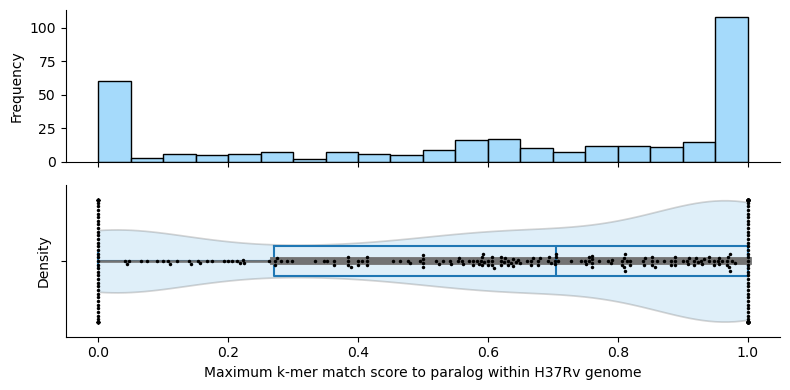

In [338]:
# Create a figure with 2 subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

# First subplot - Histogram
sns.histplot(GCE_AnnoByMatch_DF["Max_KmerMatch_ToHm"], bins=np.arange(0, 1.05, 0.05), color="#87CEFA", ax=ax1)
sns.despine(ax=ax1)
ax1.set_ylabel("Frequency")

# Second subplot - Violin and Box plot
sns.boxplot(x="Max_KmerMatch_ToHm", data=GCE_AnnoByMatch_DF, width=0.2, ax=ax2, fill=False)
sns.violinplot(x="Max_KmerMatch_ToHm", data=GCE_AnnoByMatch_DF, cut=0, color="#87CEFA", alpha=0.3, ax=ax2)
sns.swarmplot(x="Max_KmerMatch_ToHm", data=GCE_AnnoByMatch_DF, size=2.5, color="black", ax=ax2)

ax2.set_xlabel("Maximum k-mer match score to paralog within H37Rv genome")
ax2.set_ylabel("Density")
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

## Viz SNP EventToParalog Match Score distribution

In [339]:
GCE_AnnoByMatch_DF.query("Max_KmerMatch_ToHm >= 0.5").shape

(217, 46)

In [340]:
GCE_AnnoByMatch_DF.query("Max_KmerMatch_ToHm > 0.5").shape

(213, 46)

In [341]:
GCE_AnnoByMatch_DF.query("Max_SNPMatch_ToHm >= 0.5").shape

(222, 46)

In [342]:
GCE_AnnoByMatch_DF.query("Max_SNPMatch_ToHm > 0.5").shape

(209, 46)

/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 25.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


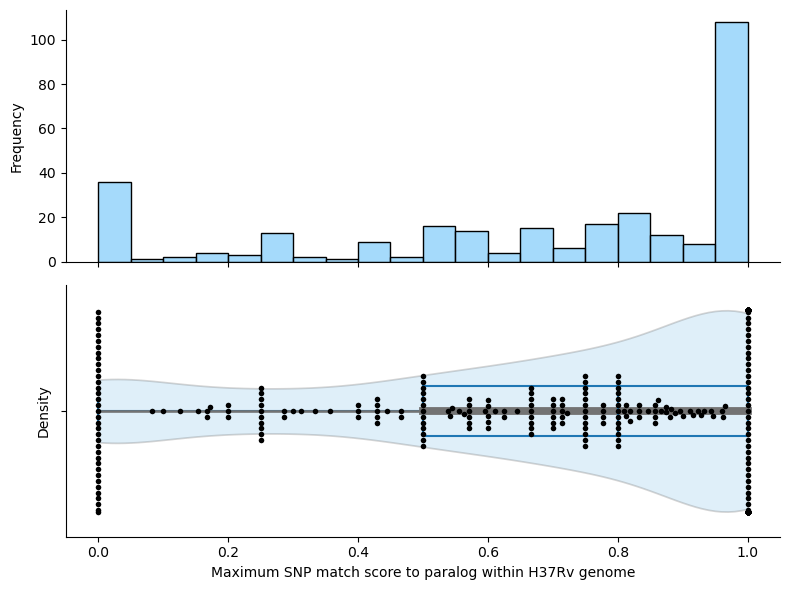

In [343]:
# Create a figure with 2 subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# First subplot - Histogram
sns.histplot(GCE_AnnoByMatch_DF["Max_SNPMatch_ToHm"],
             bins=np.arange(0, 1.05, 0.05), color="#87CEFA", ax=ax1)

sns.despine(ax=ax1)
ax1.set_ylabel("Frequency")

# Second subplot - Violin and Box plot
sns.boxplot(x="Max_SNPMatch_ToHm",    data = GCE_AnnoByMatch_DF, width=0.2, ax=ax2, fill=False)
sns.violinplot(x="Max_SNPMatch_ToHm", data = GCE_AnnoByMatch_DF, cut=0, color="#87CEFA", alpha=0.3, ax=ax2)
sns.swarmplot(x="Max_SNPMatch_ToHm",  data = GCE_AnnoByMatch_DF, size=4, color="black", ax=ax2)

ax2.set_xlabel("Maximum SNP match score to paralog within H37Rv genome")
ax2.set_ylabel("Density")
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

### Make scatterplot comparing k-mer and SNP match scores to each paralog:

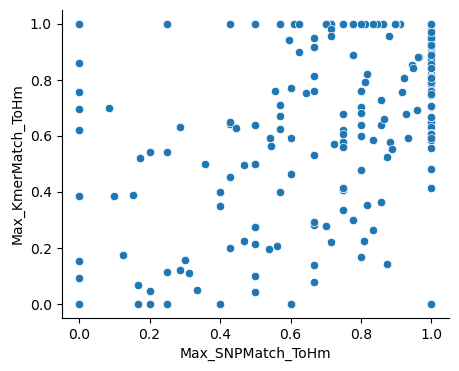

In [344]:
fig, ax= plt.subplots(1, 1, figsize=(5, 4))

# First subplot - Histogram
sns.scatterplot(x = "Max_SNPMatch_ToHm",
                y = "Max_KmerMatch_ToHm",
                data = GCE_AnnoByMatch_DF,
                ax=ax)

sns.despine()
plt.show()


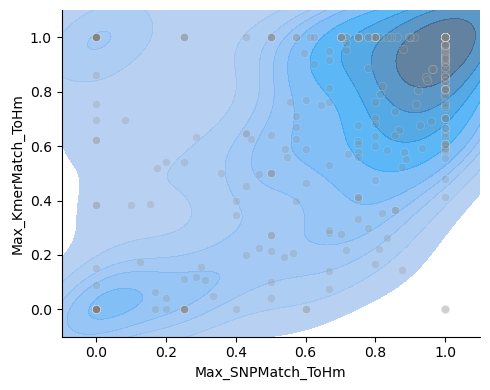

Pearson r = 0.521 (p = 6.58e-22)
Spearman rho = 0.455 (p = 1.66e-16)


In [382]:
from scipy.stats import pearsonr, spearmanr

fig, ax= plt.subplots(1, 1, figsize=(5, 4))

sns.kdeplot(
    x="Max_SNPMatch_ToHm",
    y="Max_KmerMatch_ToHm",
    data=GCE_AnnoByMatch_DF,
    ax=ax,
    fill=True,
    thresh=0.05,
    alpha=0.8,
)

# Scatterplot
sns.scatterplot(x = "Max_SNPMatch_ToHm",
                y = "Max_KmerMatch_ToHm",
                data = GCE_AnnoByMatch_DF,
                color = "grey", alpha = 0.2,
                ax=ax)


plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
    
ax.set_xlabel("Max_SNPMatch_ToHm")
ax.set_ylabel("Max_KmerMatch_ToHm")
sns.despine()
plt.tight_layout()
plt.show()

# Correlations
x = GCE_AnnoByMatch_DF["Max_SNPMatch_ToHm"]
y = GCE_AnnoByMatch_DF["Max_KmerMatch_ToHm"]
mask = x.notna() & y.notna()
x_valid = x[mask]
y_valid = y[mask]

pear_r, pear_p = pearsonr(x_valid, y_valid)
spear_rho, spear_p = spearmanr(x_valid, y_valid)

print(f"Pearson r = {pear_r:.3f} (p = {pear_p:.2e})")
print(f"Spearman rho = {spear_rho:.3f} (p = {spear_p:.2e})")

In [346]:
GCE_AnnoByMatch_DF.shape

(324, 46)

In [347]:
GCE_AnnoByMatch_DF[["Max_SNPMatch_ToHm", "Max_KmerMatch_ToHm"]].describe()

,Max_SNPMatch_ToHm,Max_KmerMatch_ToHm
count,295.000000,324.000000
mean,0.679173,0.616514
std,0.348935,0.383194
min,0.000000,0.000000
25%,0.500000,0.270325
50%,0.800000,0.704200
75%,1.000000,1.000000
max,1.000000,1.000000


### Trim Columns of mapped GC Events DF

In [348]:
Kmatch_RelevantCols = ["EventID", "EventLen", "snp_count", "seqname", "start_0based", "end_1based", "Parent_Node", "Child_Node",
                       "Overlap_Genes", "Overlap_Gene_RvIDs", "NumHmTargets", "NumHm_AtMaxKmerMatch",
                       "Top_KmerMatch_HomologTarIDs", "Max_KmerMatch_ToHm", 'TotalKmers_Eval']

mGCE_DF_Trim_DF = mGCE_DF[Kmatch_RelevantCols]
print(mGCE_DF_Trim_DF.shape)


(217, 15)


In [349]:
mGCE_DF_Trim_DF.head(3)

,EventID,EventLen,snp_count,seqname,start_0based,end_1based,Parent_Node,Child_Node,Overlap_Genes,Overlap_Gene_RvIDs,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Max_KmerMatch_ToHm,TotalKmers_Eval
0,Event_001,879,10,NC_000962.3,103599,104478,Node_148,Node_133,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...",0.8608,79
5,Event_006,1119,12,NC_000962.3,103822,104941,Node_2,N0091,"Rv0094c,Rv0095c","Rv0094c,Rv0095c",2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...",0.6972,109
8,Event_009,448,4,NC_000962.3,103835,104283,Node_69,Node_67,Rv0094c,Rv0094c,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...",0.6207,29


### How many events have a single best k-mer match? (184/213, 86%)

In [350]:
mGCE_DF_Trim_DF.query("NumHm_AtMaxKmerMatch == 1").shape

(188, 15)

In [351]:
184/213

0.863849765258216

### How many events have a multiple best k-mer matches? (29/213, 14%)

In [352]:
mGCE_DF_Trim_DF.query("NumHm_AtMaxKmerMatch > 1").shape  

(29, 15)

In [353]:
mGCEToParalogs_TopKmerMatches_Info_DF["EventID"].nunique()

217

In [354]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 14)

In [355]:
mGCE_DF_Trim_DF.head(3)

,EventID,EventLen,snp_count,seqname,start_0based,end_1based,Parent_Node,Child_Node,Overlap_Genes,Overlap_Gene_RvIDs,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Max_KmerMatch_ToHm,TotalKmers_Eval
0,Event_001,879,10,NC_000962.3,103599,104478,Node_148,Node_133,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...",0.8608,79
5,Event_006,1119,12,NC_000962.3,103822,104941,Node_2,N0091,"Rv0094c,Rv0095c","Rv0094c,Rv0095c",2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...",0.6972,109
8,Event_009,448,4,NC_000962.3,103835,104283,Node_69,Node_67,Rv0094c,Rv0094c,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...",0.6207,29


In [356]:
HmRegions_DonorAndEventCt_DF.head(3) 

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.000000,0.000000,20,20
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,0.0,0,0,0.0,0.0,0.000000,0.000000,374,374
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.5,19,31,8.5,29.5,0.288136,0.612903,68,35


In [357]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 14)

In [358]:
HM_Var_SNPs_TrimUnq_DF.shape

(52699, 6)

### Initial look at results DF

In [359]:
GCE_AnnoByMatch_DF.query(f"(Max_KmerMatch_ToHm > 0.5)").shape

(213, 46)

In [360]:
GCE_AnnoByMatch_DF["MappedEvent"].value_counts()

MappedEvent
True     217
False    107
Name: count, dtype: int64

In [361]:
print(GCE_AnnoByMatch_DF.shape)


(324, 46)


In [362]:
print(GCE_MatchToHmRegions_DF.shape)


(590, 15)


In [363]:
type(GCE_AnnoByMatch_DF)

pandas.core.frame.DataFrame

In [364]:
type(GCE_MatchToHmRegions_DF)

pandas.core.frame.DataFrame

In [365]:
type(GCE_EventMap_KmerAnalysisDict)

dict

In [366]:
print(GCE_MatchToHmRegions_DF.shape)


(590, 15)


In [367]:
GCE_AnnoByMatch_DF.head(4)

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent
0,NC_000962.3,103600,104478,.,Node_148,Node_133,1737.432787,10,"[mada_2-31, mada_1-41, MT_0080, mada_102, TB33...",103599,104038.5,879,NaN,130,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",Event_001,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,True
1,NC_000962.3,103676,103930,.,Node_3,N1177,1950.228311,5,[N1177],103675,103802.5,255,lineage6,0,Rv0094c,Rv0094c,Event_002,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,46,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False
2,NC_000962.3,103823,103846,.,Node_146,N0153,1944.165722,4,[N0153],103822,103834.0,24,lineage1,0,Rv0094c,Rv0094c,Event_003,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,28,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False
3,NC_000962.3,103823,104065,.,Node_134,R27252,2067.461166,6,[R27252],103822,103943.5,243,lineage1,0,Rv0094c,Rv0094c,Event_004,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,50,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False


In [368]:
GCE_AnnoByMatch_DF.query("NumHm_AtMaxKmerMatch > 1").shape

(50, 46)

In [369]:
GCE_AnnoByMatch_DF.query("NumHm_AtMaxKmerMatch == 1").shape

(245, 46)

#### Extra testing of data

In [370]:
HmPair_EventCt_NoPerf_DF = HmPair_EventCt_DF.query("SeqID < 99.9 & EventsMapped > 0")
print(HmPair_EventCt_DF["EventsMapped"].sum())
HmPair_EventCt_NoPerf_DF.shape

217.0


(69, 51)

In [371]:
HmPair_EventCt_NoPerf_DF = HmPair_EventCt_DF.query("SeqID < 100 & EventsMapped > 0")
print(HmPair_EventCt_DF["EventsMapped"].sum())
HmPair_EventCt_NoPerf_DF.shape

217.0


(69, 51)

In [372]:
HmPair_EventCt_DF["EventsMapped"].sum()

217.0

In [373]:
HmPair_EventCt_DF[HmPair_EventCt_DF["DonorGenes"].str.contains("PPE19")]

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
122,NC_000962.3,1532461,1533653,-,NC_000962.3,3894405,3895588,1099.0,1196.0,:28*tc:153*ga*tc:3*ga:31*ct:52*cg:46*ag:6*ag:3...,0.918896,3894996.5,1533057.0,2049592.5,1192,1183,PPE19,PPE60,False,False,0,0,NC_000962.3:1532461-1533653,NC_000962.3:3894405-3895588,NC_000962.3:1532461-1533653;NC_000962.3:389440...,59,1532461,1533653,179,3894016,3895588,PR_HmRegion_060,PR_HmRegion_182,60,182,0,0,PR_Set_36,4.0,"(2000000, 2050000]",2025000.0,PPE19,PPE60,0.210526,8,80,66.889632,2,2049592.5,2049.5925,68.158784
123,NC_000962.3,1532539,1533632,-,NC_000962.3,1339349,1340433,1009.0,1097.0,:7*tc:74*gc:2*tg*ca:74*ga*tc:3*ga:257*cg:44*gc...,0.919781,1339891.0,1533085.5,193194.5,1093,1084,PPE19,PPE18,False,False,0,0,NC_000962.3:1532539-1533632,NC_000962.3:1339349-1340433,NC_000962.3:1532539-1533632;NC_000962.3:133934...,59,1532461,1533653,52,1338923,1340433,PR_HmRegion_060,PR_HmRegion_053,60,53,0,0,PR_Set_36,3.5,"(150000, 200000]",175000.0,PPE19,PPE18,0.184211,7,71,64.721969,2,193194.5,193.1945,69.032258


In [374]:
HmPair_EventCt_DF[HmPair_EventCt_DF["AcceptorGenes"].str.contains("PPE19")]

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
102,NC_000962.3,1339349,1340433,-,NC_000962.3,1532539,1533632,1009.0,1097.0,:7*gc:3*tc:14*gc:2*tc:5*gc*gc:1*gt*gc:3*gc*gc:...,0.919781,1533085.5,1339891.0,193194.5,1084,1093,PPE18,PPE19,False,False,0,0,NC_000962.3:1339349-1340433,NC_000962.3:1532539-1533632,NC_000962.3:1339349-1340433;NC_000962.3:153253...,52,1338923,1340433,59,1532461,1533653,PR_HmRegion_053,PR_HmRegion_060,53,60,0,0,PR_Set_36,2.0,"(150000, 200000]",175000.0,PPE18,PPE19,0.105263,5,71,64.721969,2,193194.5,193.1945,67.733090
604,NC_000962.3,3894405,3895588,-,NC_000962.3,1532461,1533653,1099.0,1196.0,:5*ct:2*tc*ag:4*cg:5*ct:1*gc:5*tc:5*ag:7*ct:1*...,0.918896,1533057.0,3894996.5,2049592.5,1183,1192,PPE60,PPE19,False,False,0,0,NC_000962.3:3894405-3895588,NC_000962.3:1532461-1533653,NC_000962.3:3894405-3895588;NC_000962.3:153246...,179,3894016,3895588,59,1532461,1533653,PR_HmRegion_182,PR_HmRegion_060,182,60,0,0,PR_Set_36,3.0,"(2000000, 2050000]",2025000.0,PPE60,PPE19,0.157895,5,80,66.889632,2,2049592.5,2049.5925,67.476949


In [375]:
HmPair_EventCt_DF[HmPair_EventCt_DF["AcceptorGenes"].str.contains("PPE18")]

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
123,NC_000962.3,1532539,1533632,-,NC_000962.3,1339349,1340433,1009.0,1097.0,:7*tc:74*gc:2*tg*ca:74*ga*tc:3*ga:257*cg:44*gc...,0.919781,1339891.0,1533085.5,193194.5,1093,1084,PPE19,PPE18,False,False,0,0,NC_000962.3:1532539-1533632,NC_000962.3:1339349-1340433,NC_000962.3:1532539-1533632;NC_000962.3:133934...,59,1532461,1533653,52,1338923,1340433,PR_HmRegion_060,PR_HmRegion_053,60,53,0,0,PR_Set_36,3.5,"(150000, 200000]",175000.0,PPE19,PPE18,0.184211,7,71,64.721969,2,193194.5,193.1945,69.032258
287,NC_000962.3,2625885,2626683,-,NC_000962.3,1340494,1341292,778.0,798.0,:5*gt:77*tc:85*ca*ta:112*tc:2*cg:2*tc:238*ag:5...,0.974937,1340893.0,2626284.0,1285391.0,798,798,"esxO,esxP,Rv2348c","PPE18,esxK,esxL",False,False,0,0,NC_000962.3:2625885-2626683,NC_000962.3:1340494-1341292,NC_000962.3:2625885-2626683;NC_000962.3:134049...,111,2625885,2626683,53,1340494,1341292,PR_HmRegion_113,PR_HmRegion_054,113,54,0,0,PR_Set_28,2.5,"(1250000, 1300000]",1275000.0,"esxO,esxP,Rv2348c","PPE18,esxK,esxL",0.131579,11,20,25.062657,4,1285391.0,1285.3910,60.826033
603,NC_000962.3,3894016,3895519,+,NC_000962.3,1338923,1340433,1303.0,1541.0,:5*ct:3*ta:10*ga:1*tc:2*ct:1*ga*ca:2*ct:3*tg:1...,0.845555,1339678.0,3894767.5,1856442.5,1503,1510,"PE31,PPE60","PE13,PPE18",False,False,0,0,NC_000962.3:3894016-3895519,NC_000962.3:1338923-1340433,NC_000962.3:3894016-3895519;NC_000962.3:133892...,179,3894016,3895588,52,1338923,1340433,PR_HmRegion_182,PR_HmRegion_053,182,53,0,0,PR_Set_36,3.5,"(1850000, 1900000]",1875000.0,"PE31,PPE60","PE13,PPE18",0.184211,7,169,109.669046,2,1856442.5,1856.4425,67.637326


In [376]:
HmPair_EventCt_DF.sort_values("EventsMapped", ascending=False).head(10)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
141,NC_000962.3,1633310,1634790,+,NC_000962.3,1636705,1638392,1432.0,1693.0,:10*gc:5*tg*tc*ga:2*gt:11*ga:17-at:2+cc:7*gc*t...,0.845836,1637548.5,1634050.0,3498.5,1480,1687,PE_PGRS27,"PE_PGRS28,Rv1453",False,False,0,0,NC_000962.3:1633310-1634790,NC_000962.3:1636705-1638392,NC_000962.3:1633310-1634790;NC_000962.3:163670...,63,1633310,1634790,64,1636705,1639561,PR_HmRegion_064,PR_HmRegion_065,64,65,0,0,PR_Set_23,19.0,"(0, 50000]",25000.0,PE_PGRS27,"PE_PGRS28,Rv1453",1.000000,21,42,24.808033,3,3498.5,3.4985,76.599526
143,NC_000962.3,1636705,1638392,+,NC_000962.3,1633310,1634790,1432.0,1693.0,:10*cg:5*gt*ct*ag:2*tg:11*ag:17+at:2-cc:7*cg*c...,0.845836,1634050.0,1637548.5,3498.5,1687,1480,"PE_PGRS28,Rv1453",PE_PGRS27,False,False,0,0,NC_000962.3:1636705-1638392,NC_000962.3:1633310-1634790,NC_000962.3:1636705-1638392;NC_000962.3:163331...,64,1636705,1639561,63,1633310,1634790,PR_HmRegion_065,PR_HmRegion_064,65,64,0,0,PR_Set_23,14.0,"(0, 50000]",25000.0,"PE_PGRS28,Rv1453",PE_PGRS27,0.736842,19,42,24.808033,2,3498.5,3.4985,76.164754
159,NC_000962.3,1788513,1789865,+,NC_000962.3,103779,105130,1316.0,1354.0,:987*ct:5*ct:1*ag:6*ga:2*ag:5*ct:2*ct:5*ta*tg:...,0.971935,104454.5,1789189.0,1684734.5,1352,1351,"Rv1587c,Rv1588c","Rv0094c,Rv0095c",False,False,0,0,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865;NC_000962.3:103779...,73,1788513,1789865,2,103705,105130,PR_HmRegion_074,PR_HmRegion_002,74,2,0,0,PR_Set_3,11.5,"(1650000, 1700000]",1675000.0,"Rv1587c,Rv1588c","Rv0094c,Rv0095c",0.605263,31,33,24.372230,2,1684734.5,1684.7345,67.455621
98,NC_000962.3,1276292,1277797,-,NC_000962.3,2195856,2197360,1441.0,1506.0,:11*at:2*ag:2*cg*tc*cg:8*gt*ga:3*tc:5+t*cg:2*a...,0.956839,2196608.0,1277044.5,919563.5,1505,1504,Rv1148c,"Rv1944c,Rv1945",False,False,0,0,NC_000962.3:1276292-1277797,NC_000962.3:2195856-2197360,NC_000962.3:1276292-1277797;NC_000962.3:219585...,49,1276292,1277797,92,2195856,2197360,PR_HmRegion_050,PR_HmRegion_094,50,94,0,0,PR_Set_34,11.0,"(900000, 950000]",925000.0,Rv1148c,"Rv1944c,Rv1945",0.578947,11,62,41.168659,1,919563.5,919.5635,64.186047
103,NC_000962.3,1340494,1341292,-,NC_000962.3,2625885,2626683,778.0,798.0,:38*tc:79*ga:6*ga:6*tc:7*ag:3*ag:27*ct:5*ct:14...,0.974937,2626284.0,1340893.0,1285391.0,798,798,"PPE18,esxK,esxL","esxO,esxP,Rv2348c",False,False,0,0,NC_000962.3:1340494-1341292,NC_000962.3:2625885-2626683,NC_000962.3:1340494-1341292;NC_000962.3:262588...,53,1340494,1341292,111,2625885,2626683,PR_HmRegion_054,PR_HmRegion_113,54,113,0,0,PR_Set_28,8.0,"(1250000, 1300000]",1275000.0,"PPE18,esxK,esxL","esxO,esxP,Rv2348c",0.421053,10,20,25.062657,4,1285391.0,1285.3910,61.076345
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3,8.0,"(600000, 650000]",625000.0,"Rv0094c,Rv0095c","Rv3466,Rv3467",0.421053,17,35,25.179856,2,631701.5,631.7015,67.123288
587,NC_000962.3,3883535,3884921

In [377]:
HmRegions_DonorAndEventCt_DF["N_Events_Putative"].sum()  

296

In [378]:
HmRegions_DonorAndEventCt_DF["N_Events_Mapped"].sum()   

217

In [379]:
HmRegions_DonorAndEventCt_DF["Norm_Donor_Count"].sum()    

217.0

In [380]:
HmRegions_DonorAndEventCt_DF["EventSkew"].sum()

0.0

In [381]:
HmRegions_DonorAndEventCt_DF["EventSkew"].describe()

count    200.000000
mean       0.000000
std        1.519968
min       -5.750000
25%        0.000000
50%        0.000000
75%        0.000000
max        8.500000
Name: EventSkew, dtype: float64

# Extras

In [188]:
GCE_AnnoByMatch_DF.query(f"(Max_KmerMatch_ToHm >= 0.5)").shape

(217, 46)

In [189]:
GCE_AnnoByMatch_DF.query(f"(Max_KmerMatch_ToHm > 0.5)").shape

(213, 46)

In [190]:
GCE_AnnoByMatch_DF.query("Max_KmerMatch_ToHm > 0.5 & NumHm_AtMaxKmerMatch > 1").shape

(29, 46)

In [191]:
GCE_AnnoByMatch_DF.query("Max_KmerMatch_ToHm > 0.5 & NumHm_AtMaxKmerMatch == 1").shape

(184, 46)

In [192]:
GCE_AnnoByMatch_DF.query(f"(Max_KmerMatch_ToHm < 0.5)").shape

(107, 46)

In [193]:
GCE_AnnoByMatch_DF.query(f"(Max_KmerMatch_ToHm >= 0.5)").shape

(217, 46)

In [194]:
GCE_AnnoByMatch_DF.query(f"(Max_KmerMatch_ToHm < 0.5)").head(5)

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent
1,NC_000962.3,103676,103930,.,Node_3,N1177,1950.228311,5,[N1177],103675,103802.5,255,lineage6,0,Rv0094c,Rv0094c,Event_002,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0000,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,46,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,False
2,NC_000962.3,103823,103846,.,Node_146,N0153,1944.165722,4,[N0153],103822,103834.0,24,lineage1,0,Rv0094c,Rv0094c,Event_003,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0000,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,28,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,False
3,NC_000962.3,103823,104065,.,Node_134,R27252,2067.461166,6,[R27252],103822,103943.5,243,lineage1,0,Rv0094c,Rv0094c,Event_004,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0000,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,50,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,False
4,NC_000962.3,103823,104712,.,Node_4,Node_3,3155.350126,7,"[N1177, N1202, N0091]",103822,104267.0,890,lineage6,3,Rv0094c,Rv0094c,Event_005,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,3,False,0.0000,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.1528,NaN,72,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,False
6,NC_000962.3,103823,105000,.,Node_149,RW-TB008,4639.341065,16,[RW-TB008],103822,104411.0,1178,lineage8,0,"Rv0094c,Rv0095c","Rv0094c,Rv0095c",Event_007,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,3,1,1,True,0.0625,2,1,"Rv3466,Rv3467-H37Rv-3883535-3884921","Rv3466,Rv3467",0.1077,631715.0,130,1,"Rv3466,Rv3467-H37Rv-3883535-3884921","Rv3466,Rv3467",0.3125,631715.0,False
